# תרגום כל הדטאות לאנגלית עיבוד ראשוני ואיחוד לדאטה אחת

## תרגום הדאטאות סגמנטים וסגמנטים עם מעקות לאנגלית

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
pd.set_option('display.max_columns', None)

In [2]:
import os
print(os.getcwd())# תריצו את זה ותוודאו שהנתיב לקבצים הוא נכון ,כי אם לא תצטרכו כל פעם לשנות את הנתיב לקבצים וזה כאב ראש


C:\Users\USER\final_project


### טעינת הדאטה עיקולים

In [3]:
curves = pd.read_excel("עיקולים.xls", engine='xlrd')
curves.head()

,כביש,כיוון,נתיב,היסט מאונך,"ק""מ התחלה","ק""מ סוף",רדיוס ממוצע,רדיוס מינימאלי,סיום X,התחלה X,Y,Y End,תאונה קלה,תאונה קשה,תאונה קטלנית,תאונות כללי,שיפוע צד מקס',שיפוע צד מינ',Grade Max,Grade Min,מהירות תכן לפי רדיוס,"מהירות מותרת ק""מ עולה",מהירות רצויה לפי סוג דרך,הבדל מהירות תכן לרצוי,סוג קטע,שנת IRI,מזהה רדיוס,תאריך עידכון
0,4,שניהם,כל הנתיבים,0.0,122.788,122.892,-518.7968,193.7823,186743.62253,186645.47723,670262.7877,670324.2752,37,8,1,46,NaN,NaN,NaN,NaN,70,90.0,90.0,כן,NaN,2023.0,4_1_97,2020-12-06 10:55:28
1,4,שניהם,כל הנתיבים,0.0,122.500,122.594,-642.7314,455.6653,186493.15561,186431.60220,670026.6043,670110.4138,36,8,1,45,NaN,NaN,NaN,NaN,100,90.0,90.0,לא,NaN,2023.0,4_1_96,2020-12-06 10:55:28
2,4,שניהם,כל הנתיבים,0.0,123.078,123.211,-511.1088,142.8261,187055.36405,186925.04000,670403.4333,670433.0063,35,8,0,43,NaN,NaN,NaN,NaN,60,90.0,90.0,כן,NaN,2023.0,4_1_98,2020-12-06 10:55:28
3,22,שניהם,כל הנתיבים,0.0,7.909,8.831,632.4401,317.9796,208886.91761,208218.58577,746310.6194,746871.3427,29,2,1,32,NaN,NaN,NaN,NaN,80,90.0,100.0,כן,NaN,2023.0,22_0_16,2020-12-06 10:53:45
4,4,שניהם,כל הנתיבים,0.0,109.402,109.618,-569.8891,248.7093,182771.21176,182653.09885,657629.1822,657787.3189,19,8,1,28,NaN,NaN,NaN,NaN,80,90.0,90.0,כן,NaN,2023.0,4_1_25,2020-12-06 10:55:28


In [4]:
column_mapping = {
    'כביש': 'Road',
    'כיוון': 'Direction',
    'נתיב': 'Lane',
    'היסט מאונך': 'Lateral Offset',
    'ק"מ התחלה': 'Start KM',
    'ק"מ סוף': 'End KM',
    'רדיוס ממוצע': 'Average Radius',
    'רדיוס מינימאלי': 'Minimal Radius',
    'סיום X': 'End X',
    'התחלה X': 'Start X',
    'Y': 'Y',
    'Y End': 'Y End',
    'תאונה קלה': 'Minor Accident',
    'תאונה קשה': 'Severe Accident',
    'תאונה קטלנית': 'Fatal Accident',
    'תאונות כללי': 'Total Accidents',
    "שיפוע צד מקס'": 'Max Side Slope',
    "שיפוע צד מינ'": 'Min Side Slope',
    'Grade Max': 'Grade Max',
    'Grade Min': 'Grade Min',
    'מהירות תכן לפי רדיוס': 'Design Speed by Radius',
    'מהירות מותרת ק"מ עולה': 'Allowed Speed (Ascending KM)',
    'מהירות רצויה לפי סוג דרך': 'Desired Speed by Road Type',
    'הבדל מהירות תכן לרצוי': 'Design-Desired Speed Difference',
    'סוג קטע': 'Segment Type',
    'שנת IRI': 'IRI Year',
    'מזהה רדיוס': 'Radius ID',
    'תאריך עידכון': 'Update Date'
}

curves.rename(columns=column_mapping, inplace=True)

In [5]:
curves.isna().sum()

Road                                 734
Direction                            644
Lane                                 644
Lateral Offset                       644
Start KM                             644
End KM                               644
Average Radius                         0
Minimal Radius                         0
End X                                  0
Start X                                0
Y                                      0
Y End                                  0
Minor Accident                         0
Severe Accident                        0
Fatal Accident                         0
Total Accidents                        0
Max Side Slope                     19844
Min Side Slope                     19844
Grade Max                          19844
Grade Min                          19844
Design Speed by Radius                 0
Allowed Speed (Ascending KM)        6294
Desired Speed by Road Type          4301
Design-Desired Speed Difference        0
Segment Type    

## הורדת פיצ'רים לא רלוונטים או חסרים במידע ביותר מ95 אחוז מהם

### יש פה המון פיצ'רים ש95 אחוז מהם חסרים במידע ,חלק מהפיצ'רים לא רלוונטים למשל כמו UPDATE YEAR
### Allowed speed and Desire speed by road נמצאים בדאטא אחר שקיים לנו 

In [6]:
curves= curves.drop(columns=['Direction','Lane','Max Side Slope','Lateral Offset','Max Side Slope','Min Side Slope','Grade Max','Grade Min','Segment Type','Design-Desired Speed Difference','Radius ID','Update Date','IRI Year','Allowed Speed (Ascending KM)','Desired Speed by Road Type','Minor Accident','Severe Accident','Fatal Accident','Total Accidents','Minimal Radius'])

### הורדנו את השורות בהם לא מצוין כביש כי אם לא מצוין כביש לא נוכל להבין על איזה כביש מדובר

In [7]:
curves=curves.dropna(subset='Road')

In [8]:
curves = curves[curves['Road'].str.match(r'^[A-Za-z]', na=False)==False]

In [9]:
curves['Road']=curves['Road'].astype('int64')

In [10]:
curves.head()

,Road,Start KM,End KM,Average Radius,End X,Start X,Y,Y End,Design Speed by Radius
0,4,122.788,122.892,-518.7968,186743.62253,186645.47723,670262.7877,670324.2752,70
1,4,122.500,122.594,-642.7314,186493.15561,186431.60220,670026.6043,670110.4138,100
2,4,123.078,123.211,-511.1088,187055.36405,186925.04000,670403.4333,670433.0063,60
3,22,7.909,8.831,632.4401,208886.91761,208218.58577,746310.6194,746871.3427,80
4,4,109.402,109.618,-569.8891,182771.21176,182653.09885,657629.1822,657787.3189,80


In [11]:
curves.isna().sum()

Road                      0
Start KM                  0
End KM                    0
Average Radius            0
End X                     0
Start X                   0
Y                         0
Y End                     0
Design Speed by Radius    0
dtype: int64

## טעינת נתוני הסגמנטים

In [12]:
Segments = pd.read_csv("סגמנטים.csv", encoding="utf-8")
Segments.head()

C:\Users\USER\AppData\Local\Temp\ipykernel_12264\1425065863.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  Segments = pd.read_csv("סגמנטים.csv", encoding="utf-8")


,כביש,"ק""מ התחלה","ק""מ סוף",קוד סגמנט,קוד צפון/דרום,רוחב נתיב ממוצע,AADT נפח תנועה יומי,מרחב,"מספר נתיבים - ק""מ עולה","מספר נתיבים - ק""מ יורד",מספר נתיבים כללי,"מהירות מותרת ק""מ עולה","רוחב מסלול - ק""מ יורד",קוד סוג הפרדה בין כיווני נסיעה,"רוחב מסלול - ק""מ עולה",רדיוס אופקי,שיפוע צידי,"מהירות מותרת ק""מ יורד",רוחב מפרדה (מ') מינימלי,אזור,"מכשול במפרדה - ק""מ",נתיב,סוג מכשול במפרדה,קוד מבנה מכשול במפרדה,שיפוע ממוצע
0,1,1.0,1.1,10095795.0,סקרים צפון,NaN,157316.0,מרחב מרכז,3.0,3.0,6.0,90.0,11.060,מעקה,11.289,43851.3939,1.5050,90.0,NaN,מרכז,NaN,כל הנתיבים,NaN,NaN,0.4346
1,1,1.1,1.2,10095796.0,סקרים צפון,NaN,157316.0,מרחב מרכז,3.0,3.0,6.0,90.0,11.060,מעקה,11.454,105129.6475,2.1067,110.0,NaN,מרכז,NaN,כל הנתיבים,NaN,NaN,0.4315
2,1,1.2,1.3,10095797.0,סקרים צפון,NaN,157316.0,מרחב מרכז,3.0,3.0,6.0,90.0,19.938,מעקה,11.454,50667.4978,1.9600,110.0,NaN,מרכז,NaN,כל הנתיבים,NaN,NaN,0.4212
3,1,1.3,1.4,10095798.0,סקרים צפון,NaN,157316.0,מרחב מרכז,3.0,3.0,6.0,90.0,19.938,מעקה,11.454,104363.7075,2.1892,110.0,NaN,מרכז,NaN,כל הנתיבים,NaN,NaN,0.4177
4,1,1.4,1.5,10095799.0,סקרים צפון,NaN,157316.0,מרחב מרכז,3.0,3.0,6.0,90.0,19.938,מעקה,11.031,102843.4453,2.4903,110.0,NaN,מרכז,NaN,כל הנתיבים,NaN,NaN,0.4150


### עמודות שהיו ריקות לגמרי הורדנו מהדאטה

In [13]:
columns_to_remove = ["רוחב נתיב ממוצע", "רוחב מפרדה (מ') מינימלי", 'מכשול במפרדה - ק"מ', "סוג מכשול במפרדה", "קוד מבנה מכשול במפרדה",]

הורדנו מהדאטה עמודות לא רלוונטיות (כל הערכים בהם אותו דבר או מוסיפים מידע לא חשוב)

In [14]:
columns_to_remove2 = ["קוד סגמנט", "קוד צפון/דרום", 'אזור', "נתיב"]

Segments = Segments.drop(columns=columns_to_remove+columns_to_remove2)
Segments.head()

,כביש,"ק""מ התחלה","ק""מ סוף",AADT נפח תנועה יומי,מרחב,"מספר נתיבים - ק""מ עולה","מספר נתיבים - ק""מ יורד",מספר נתיבים כללי,"מהירות מותרת ק""מ עולה","רוחב מסלול - ק""מ יורד",קוד סוג הפרדה בין כיווני נסיעה,"רוחב מסלול - ק""מ עולה",רדיוס אופקי,שיפוע צידי,"מהירות מותרת ק""מ יורד",שיפוע ממוצע
0,1,1.0,1.1,157316.0,מרחב מרכז,3.0,3.0,6.0,90.0,11.060,מעקה,11.289,43851.3939,1.5050,90.0,0.4346
1,1,1.1,1.2,157316.0,מרחב מרכז,3.0,3.0,6.0,90.0,11.060,מעקה,11.454,105129.6475,2.1067,110.0,0.4315
2,1,1.2,1.3,157316.0,מרחב מרכז,3.0,3.0,6.0,90.0,19.938,מעקה,11.454,50667.4978,1.9600,110.0,0.4212
3,1,1.3,1.4,157316.0,מרחב מרכז,3.0,3.0,6.0,90.0,19.938,מעקה,11.454,104363.7075,2.1892,110.0,0.4177
4,1,1.4,1.5,157316.0,מרחב מרכז,3.0,3.0,6.0,90.0,19.938,מעקה,11.031,102843.4453,2.4903,110.0,0.4150


In [15]:
Segments.describe()

,"ק""מ התחלה","ק""מ סוף",AADT נפח תנועה יומי,"מספר נתיבים - ק""מ עולה","מספר נתיבים - ק""מ יורד",מספר נתיבים כללי,"מהירות מותרת ק""מ עולה","רוחב מסלול - ק""מ יורד","רוחב מסלול - ק""מ עולה",רדיוס אופקי,שיפוע צידי,"מהירות מותרת ק""מ יורד",שיפוע ממוצע
count,62233.000000,62233.000000,62233.000000,57600.000000,55973.000000,58055.000000,57486.000000,55973.000000,57600.000000,5.903600e+04,59014.000000,55037.000000,59591.000000
mean,52.988959,53.089730,18517.669855,1.278142,1.252854,2.450556,76.458964,5.704653,6.080127,3.279187e+04,8.949532,76.646438,9.127215
std,86.996807,86.996719,25531.898565,0.530545,0.546494,1.093454,13.975392,3.063966,33.558346,3.291395e+04,42.283827,14.287302,39.922831
min,0.000000,0.012000,105.000000,0.000000,0.000000,0.000000,30.000000,0.000000,0.000000,3.960500e+01,0.000000,30.000000,0.000000
25%,2.297000,2.397000,2540.200000,1.000000,1.000000,2.000000,70.000000,3.600000,3.590000,1.616695e+04,1.421225,70.000000,1.238900
50%,13.289000,13.391000,7574.000000,1.000000,1.000000,2.000000,80.000000,5.597000,5.708000,2.299195e+04,1.939400,80.000000,1.989000
75%,60.289000,60.384000,23989.000000,1.000000,1.000000,2.000000,80.000000,7.260000,7.326000,3.681231e+04,2.678200,80.000000,3.680250
max,478.955000,479.055000,200055.800000,4.000000,5.000000,8.000000,110.000000,307.000000,4020.000000,1.768878e+06,999.000000,110.000000,999.000000


In [16]:
Segments.dtypes

כביש                               object
ק"מ התחלה                         float64
ק"מ סוף                           float64
AADT נפח תנועה יומי               float64
מרחב                               object
מספר נתיבים - ק"מ עולה            float64
מספר נתיבים - ק"מ יורד            float64
מספר נתיבים כללי                  float64
מהירות מותרת ק"מ עולה             float64
רוחב מסלול - ק"מ יורד             float64
קוד סוג הפרדה בין כיווני נסיעה     object
רוחב מסלול - ק"מ עולה             float64
רדיוס אופקי                       float64
שיפוע צידי                        float64
מהירות מותרת ק"מ יורד             float64
שיפוע ממוצע                       float64
dtype: object

## החלפת שמות העמודות לאנגלית

הסיבה שעשינו את זה ,כי נורא קשה ומסורבל לעבוד עם נתונים בעברית

In [17]:

column_mapping = {
    "כביש": "Road",
    "ק\"מ התחלה": "Start Km",
    "ק\"מ סוף": "End Km",
    "AADT נפח תנועה יומי": "AADT Daily Traffic Volume",
    "מרחב": "Region",
    "מספר נתיבים - ק\"מ עולה": "Lanes Up Km",
    "מספר נתיבים - ק\"מ יורד": "Lanes Down Km",
    "מספר נתיבים כללי": "Total Lanes",
    "מהירות מותרת ק\"מ עולה": "Speed Limit Up Km",
    "רוחב מסלול - ק\"מ יורד": "Lane Width Down Km",
    "קוד סוג הפרדה בין כיווני נסיעה": "Separation Type Code",
    "רוחב מסלול - ק\"מ עולה": "Lane Width Up Km",
    "רדיוס אופקי": "Horizontal Radius",
    "שיפוע צידי": "Side Slope",
    "מהירות מותרת ק\"מ יורד": "Speed Limit Down Km",
    "שיפוע ממוצע": "Average Slope"
}

Segments.rename(columns=column_mapping, inplace=True)


## המרת ערכים בתוך העמודות לאנגלית

In [18]:
Segments["Separation Type Code"].value_counts()

Separation Type Code
קו הפרדה מקווקו                       16704
קו הפרדה רצוף כפול                    13441
מעקה                                   5348
מעקה עם צבע                            4992
בנוי עם מעקה                           4445
בנוי ללא מעקה                          2817
איזור עקיפה - קו הפרדה מקווקו-רציף      937
אין מפרדה                               825
קו הפרדה רציף                           329
אי תנועה מסומן על הכביש                  65
Name: count, dtype: int64

In [19]:

separation_mapping = {
    "קו הפרדה מקווקו": "Dashed Separation Line",
    "קו הפרדה רצוף כפול": "Double Solid Separation Line",
    "מעקה": "Barrier",
    "מעקה עם צבע": "Barrier with Paint",
    "בנוי עם מעקה": "Built with Barrier",
    "בנוי ללא מעקה": "Built without Barrier",
    "איזור עקיפה - קו הפרדה מקווקו-רציף": "Overtaking Zone - Dashed-Solid Line",
    "אין מפרדה": "No Separator",
    "קו הפרדה רציף": "Solid Separation Line",
    "אי תנועה מסומן על הכביש": "Traffic Island Marked on Road"
}


Segments["Separation Type Code"] = Segments["Separation Type Code"].replace(separation_mapping)

ניתוח יותר לעומק של הדאטא הזו ##

שמנו לב שבנתונים האלו בעמודה של כבישים ישנם שמות עם אותיות 
לאחר בירור ההבנה הייתה שמדובר במחלפים ,החלטנו בשלב זה לא להתייחס אליהם כי שאר הנתונים שלנו לא מתייחסים למחלפים 

In [20]:
Segments = Segments[Segments['Road'].str.match(r'^[A-Za-z]', na=False)==False]

In [21]:
Segments['Road']=Segments['Road'].astype('int64')

In [22]:
Segments.isna().sum()

Road                             0
Start Km                         0
End Km                           0
AADT Daily Traffic Volume        0
Region                           0
Lanes Up Km                   3429
Lanes Down Km                 3456
Total Lanes                   3411
Speed Limit Up Km             3439
Lane Width Down Km            3456
Separation Type Code         11495
Lane Width Up Km              3429
Horizontal Radius             2667
Side Slope                    2678
Speed Limit Down Km           3471
Average Slope                 2161
dtype: int64

פה השתמשנו בטכניקה של KNN 

כדי למלא ערכים חסרים ,הוא מוצא שורות שתואמות לאותה שורה שיש בה ערכים חסרים בעמודה הנבחרת ועושה ממוצע רק על השורות הכי קרובות לשורה שבה חסר נתון וממלא אותה בממוצע המתקבל.

In [23]:
imputer = KNNImputer(n_neighbors=4)

for column in Segments.columns:
    if Segments[column].isna().sum() >0 and Segments[column].dtypes != 'object':
        Segments[[column]] = imputer.fit_transform(Segments[[column]])

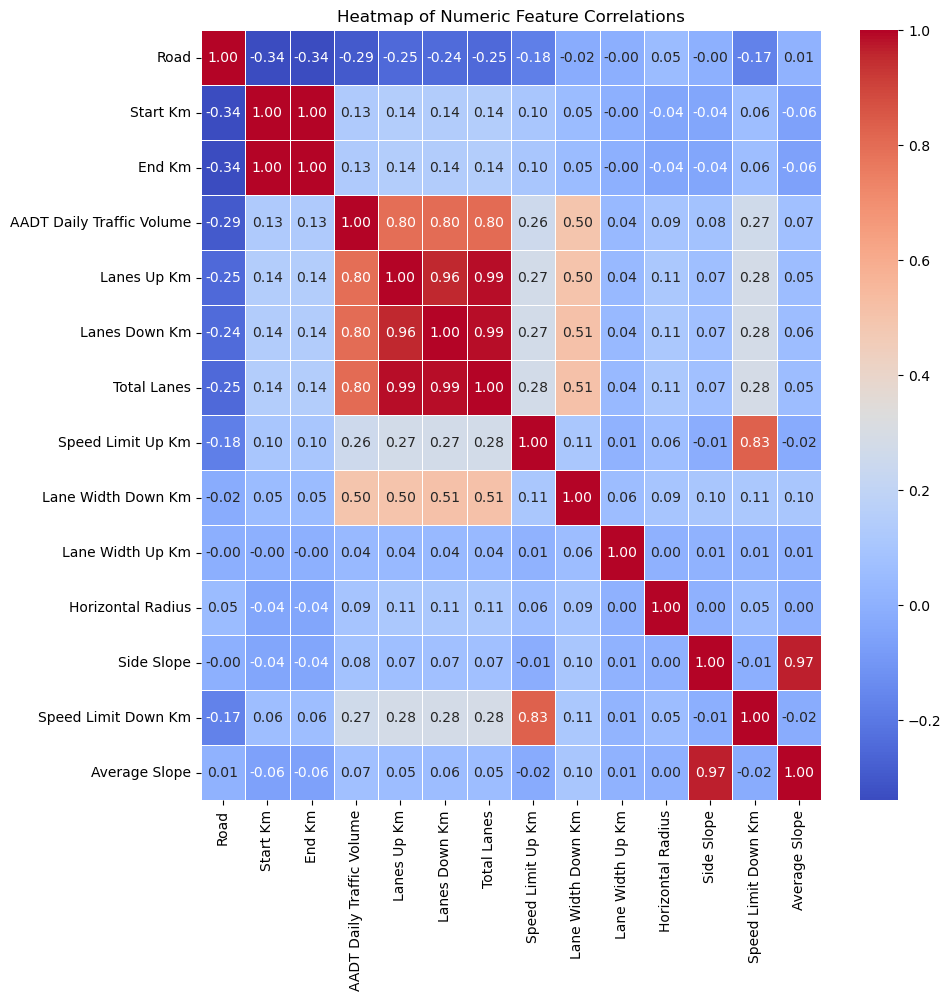

In [24]:
df_numeric = Segments.select_dtypes(include=['number'])
correlation_matrix = df_numeric.corr()
plt.figure(figsize=(10, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap of Numeric Feature Correlations')
plt.show()


בדקנו קורולציה בנתונים שלנו ,יש המון פיצ'רים שהקורולציה בינהם מאוד חזקה ולכן הורדנו את הרוב והשארנו אחד ,לדוגמא

Total Lanes

Lanes Down Km 

Lanes Up Km

עם קורולציה של כ0.9 בינהם ולכן העדפנו לקחת את עמודת טוטאל ליינס ואת השניים האחרים להוריד כדי לחסוך במימדים

In [25]:
Segments = Segments.drop(columns=['Lanes Up Km','Lanes Down Km'])

In [26]:
Segments

,Road,Start Km,End Km,AADT Daily Traffic Volume,Region,Total Lanes,Speed Limit Up Km,Lane Width Down Km,Separation Type Code,Lane Width Up Km,Horizontal Radius,Side Slope,Speed Limit Down Km,Average Slope
0,1,1.000,1.100,157316.0,מרחב מרכז,6.000000,90.000000,11.060000,Barrier,11.28900,43851.393900,1.50500,90.000000,0.434600
1,1,1.100,1.200,157316.0,מרחב מרכז,6.000000,90.000000,11.060000,Barrier,11.45400,105129.647500,2.10670,110.000000,0.431500
2,1,1.200,1.300,157316.0,מרחב מרכז,6.000000,90.000000,19.938000,Barrier,11.45400,50667.497800,1.96000,110.000000,0.421200
3,1,1.300,1.400,157316.0,מרחב מרכז,6.000000,90.000000,19.938000,Barrier,11.45400,104363.707500,2.18920,110.000000,0.417700
4,1,1.400,1.500,157316.0,מרחב מרכז,6.000000,90.000000,19.938000,Barrier,11.03100,102843.445300,2.49030,110.000000,0.415000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62223,4312,1.854,1.935,2500.0,מרחב מרכז,2.546964,76.839334,5.794391,NaN,6.11347,31979.549553,9.25817,76.783305,9.490372
62224,4312,1.935,2.016,2500.0,מרחב מרכז,2.546964,76.839334,5.794391,NaN,6.11347,31979.549553,9.25817,76.783305,9.490372
62225,4312,2.016,2.097,2500.0,מרחב מרכז,2.546964,76.839334,5.794391,NaN,6.11347,31979.549553,9.25817,76.783305,9.490372
62226,4312,2.097,2.178,2500.0,מרחב מרכז,2.546964,76.839334,5.794391,NaN,6.11347,31979.549553,9.25817,76.783305,9.490372


פה החלטנו לאחד בין המהירות המותרת לשני הנתיבים בעזרת ממוצע כך שנקבל עמודה אחת במקום שניים 

In [27]:
Segments["Speed Limit Avg"] = Segments[["Speed Limit Up Km", "Speed Limit Down Km"]].mean(axis=1)
Segments = Segments.drop(columns=["Speed Limit Up Km", "Speed Limit Down Km"])


ניתן לראות שעמודות 

Side slope 

Average Slope 

עם קורולוציה מאוד חזקה בינהם ,מאחר ונתונים שלהם כמעט זהים .

החלטנו לקחת את עמודת Average Slope




In [28]:
Segments=Segments.drop(columns=['Side Slope'])

#### טיפול העמודה Separation Type Code

In [29]:
Segments['Separation Type Code'].value_counts()

Separation Type Code
Dashed Separation Line                 16577
Double Solid Separation Line           13236
Barrier                                 5263
Barrier with Paint                      4624
Built without Barrier                   2680
Built with Barrier                      1938
Overtaking Zone - Dashed-Solid Line      934
No Separator                             457
Solid Separation Line                    303
Traffic Island Marked on Road             63
Name: count, dtype: int64

In [30]:
# מילון לאיחוד ערכים עם שמות דומים
separation_mapping = {
    "Dashed Separation Line": "Dashed Line",
    "Double Solid Separation Line": "Solid Line",
    "Solid Separation Line": "Solid Line",
    "Overtaking Zone - Dashed-Solid Line": "Dashed-Solid Line",

    "Barrier": "Barrier",
    "Barrier with Paint": "Barrier",
    "Built with Barrier": "Barrier",
    "Built without Barrier": "No Barrier",

    "No Separator": "No Separator",
    "Traffic Island Marked on Road": "Traffic Island Marked on Road"
}

# החלת המיפוי על העמודה
Segments['Separation Type Code'] = Segments['Separation Type Code'].replace(separation_mapping)

# צפייה בערכים החדשים עם ספירה
Segments['Separation Type Code'].value_counts()


Separation Type Code
Dashed Line                      16577
Solid Line                       13539
Barrier                          11825
No Barrier                        2680
Dashed-Solid Line                  934
No Separator                       457
Traffic Island Marked on Road       63
Name: count, dtype: int64

In [31]:
Segments['Separation Type Code']

0        Barrier
1        Barrier
2        Barrier
3        Barrier
4        Barrier
          ...   
62223        NaN
62224        NaN
62225        NaN
62226        NaN
62227        NaN
Name: Separation Type Code, Length: 57570, dtype: object

In [32]:
import pandas as pd
from sklearn.impute import KNNImputer

# שלב 0 – העתקת הדאטה
df = Segments.copy()
col_to_impute = 'Separation Type Code'
original_index = df.index

# שלב 1 – יצירת one-hot כולל NaNs
encoded_col = pd.get_dummies(df[col_to_impute], prefix=col_to_impute)

# שלב 2 – חיבור עם עמודות מספריות לצורך חישוב דמיון
numeric_cols = df.select_dtypes(include=['number'])
df_for_imputation = pd.concat([numeric_cols.reset_index(drop=True), encoded_col.reset_index(drop=True)], axis=1)

# שלב 3 – KNN אימפוטציה
imputer = KNNImputer(n_neighbors=5)
imputed = imputer.fit_transform(df_for_imputation)

# שלב 4 – שחזור הערכים המקודדים מתוך ה-one-hot
imputed_onehot = imputed[:, -encoded_col.shape[1]:]
decoded_labels = pd.DataFrame(imputed_onehot, columns=encoded_col.columns)
imputed_categories = decoded_labels.idxmax(axis=1).str.replace(f'{col_to_impute}_', '')

# שלב 5 – החזרת ערכים לעמודה המקורית
df[col_to_impute] = df[col_to_impute].fillna(imputed_categories)

# שלב 6 – מילוי שארית הערכים החסרים ב-mode
still_missing = df[col_to_impute].isna()
if still_missing.any():
    most_common = df[col_to_impute].mode()[0]
    df.loc[still_missing, col_to_impute] = most_common
    print(f"Filled remaining {still_missing.sum()} missing values with mode: {most_common}")

# שלב 7 – עדכון סופי בדאטה שלך
Segments[col_to_impute] = df[col_to_impute]

# בדיקה
print("סה\"כ ערכים חסרים לאחר ההשלמה:", Segments[col_to_impute].isna().sum())
Segments[col_to_impute].value_counts(dropna=False)


Filled remaining 1501 missing values with mode: Barrier
סה"כ ערכים חסרים לאחר ההשלמה: 0


Separation Type Code
Barrier                          22058
Dashed Line                      17217
Solid Line                       13977
No Barrier                        2783
Dashed-Solid Line                  960
No Separator                       512
Traffic Island Marked on Road       63
Name: count, dtype: int64

In [33]:
Segments.head(10)

,Road,Start Km,End Km,AADT Daily Traffic Volume,Region,Total Lanes,Lane Width Down Km,Separation Type Code,Lane Width Up Km,Horizontal Radius,Average Slope,Speed Limit Avg
0,1,1.0,1.1,157316.0,מרחב מרכז,6.0,11.060,Barrier,11.289,43851.3939,0.4346,90.0
1,1,1.1,1.2,157316.0,מרחב מרכז,6.0,11.060,Barrier,11.454,105129.6475,0.4315,100.0
2,1,1.2,1.3,157316.0,מרחב מרכז,6.0,19.938,Barrier,11.454,50667.4978,0.4212,100.0
3,1,1.3,1.4,157316.0,מרחב מרכז,6.0,19.938,Barrier,11.454,104363.7075,0.4177,100.0
4,1,1.4,1.5,157316.0,מרחב מרכז,6.0,19.938,Barrier,11.031,102843.4453,0.4150,100.0
5,1,1.5,1.6,157316.0,מרחב מרכז,6.0,19.938,Barrier,11.454,165988.2764,0.4236,100.0
6,1,1.6,1.7,157316.0,מרחב מרכז,6.0,19.938,Barrier,10.886,79237.4556,0.4229,100.0
7,1,1.7,1.8,157316.0,מרחב מרכז,6.0,19.938,Barrier,10.886,51251.4411,0.4277,100.0
8,1,1.8,1.9,157316.0,מרחב מרכז,6.0,19.938,Barrier,10.886,76161.2442,0.4340,100.0
9,1,1.9,2.0,157316.0,מרחב מרכז,6.0,19.938,Barrier,11.454,67723.1284,0.4300,100.0


In [34]:
Segments.isna().sum()

Road                         0
Start Km                     0
End Km                       0
AADT Daily Traffic Volume    0
Region                       0
Total Lanes                  0
Lane Width Down Km           0
Separation Type Code         0
Lane Width Up Km             0
Horizontal Radius            0
Average Slope                0
Speed Limit Avg              0
dtype: int64

In [35]:
Segments.describe()

,Road,Start Km,End Km,AADT Daily Traffic Volume,Total Lanes,Lane Width Down Km,Lane Width Up Km,Horizontal Radius,Average Slope,Speed Limit Avg
count,57570.000000,57570.000000,57570.000000,57570.000000,57570.000000,57570.000000,57570.000000,5.757000e+04,57570.000000,57570.000000
mean,1634.952823,57.250085,57.350750,17779.217406,2.546964,5.794391,6.113470,3.197955e+04,9.490372,76.811319
std,2684.082043,89.101812,89.101787,25048.452254,1.010655,2.904809,33.561016,2.990140e+04,39.813876,12.907022
min,1.000000,0.000000,0.012000,105.000000,0.000000,0.000000,0.000000,3.979000e+01,0.000000,30.000000
25%,65.000000,3.697250,3.798250,2616.800000,2.000000,3.600000,3.600000,1.623961e+04,1.293800,70.000000
50%,293.000000,16.461500,16.567000,7500.000000,2.000000,5.794391,6.110000,2.331467e+04,2.169700,80.000000
75%,989.000000,67.686500,67.785750,21871.000000,2.546964,7.220000,7.295000,3.407571e+04,4.110800,80.000000
max,9991.000000,478.955000,479.055000,200055.800000,8.000000,307.000000,4020.000000,1.100877e+06,499.857100,110.000000


ייצוא לקובץ

In [36]:
#Segments.to_csv("Segments_fixed_file.csv", index=False)

# טעינת הדאטה סגמנטים עם מעקות

In [37]:
segments_with_barriers = pd.read_csv("סגמנטים עם מעקה.csv", encoding="utf-8")
segments_with_barriers

C:\Users\USER\AppData\Local\Temp\ipykernel_12264\522480275.py:1: DtypeWarning: Columns (2,4) have mixed types. Specify dtype option on import or set low_memory=False.
  segments_with_barriers = pd.read_csv("סגמנטים עם מעקה.csv", encoding="utf-8")


,תאריך,קוד צפון/דרום,מרחק נקי ממעקה עד למכשול/תעלה/מדרון,ILS GUARD OBJECTID2,גובה מעקה בטיחות מינימום,העדר אלמנט קצה של מעקה במפרדה,העדר אלמנט קצה של מעקה בצד הדרך,כביש,כיוון,מרחב,מרחק מהמיסעה למעקה,נתיב,סוג אבן שפה במפרדה,"ק""מ התחלה","ק""מ סוף",קוד דגם מעקה,קוד מיקום מעקה,קוד סגמנט,קוד סוג חומר המעקה,קוד סוג אלמנט קצה של מעקה,קוד סוג מעקה,קוד סוג סופג אנרגיה התחלה,קוד סיבה להתקנת מעקה
0,18/6/2019,סקרים דרום,1.14,1929,.7000,NaN,NaN,241,שניהם,מרחב דרום,2.8600,כל הנתיבים,NaN,16.070,16.162,NaN,"R - ק""מ עולה",656.0,פלדה,NaN,פלדה EUR,NaN,NaN
1,28/4/2019,סקרים דרום,0.9,1930,.7000,NaN,NaN,232,שניהם,מרחב דרום,1.3000,כל הנתיבים,NaN,50.983,51.096,NaN,"L - ק""מ יורד",1275.0,פלדה,NaN,פלדה W,NaN,NaN
2,29/4/2019,סקרים דרום,0.0,1927,.7500,NaN,NaN,204,שניהם,מרחב דרום,2.9000,כל הנתיבים,NaN,162.822,162.921,NaN,"R - ק""מ עולה",5077.0,פלדה,NaN,פלדה W,NaN,NaN
3,7/1/2019,סקרים דרום,0.0,1928,1.0000,NaN,NaN,1,שניהם,מרחב מרכז,0.8200,כל הנתיבים,NaN,43.466,43.570,NaN,C - מפרדה בודד,109540039.0,בטון,NaN,בטון מקטעים,NaN,NaN
4,7/1/2019,סקרים דרום,0.0,1926,.9000,NaN,NaN,1,שניהם,"מרחב יו""ש",2.6300,כל הנתיבים,NaN,77.479,77.579,NaN,"R - ק""מ עולה",5542.0,פלדה,NaN,פלדה EUR,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74635,4/11/2019,סקרים צפון,.7003,8018,0.5514,NaN,NaN,5714,שניהם,מרחב מרכז,1.5190,כל הנתיבים,NaN,4.697,4.801,NaN,"L - ק""מ יורד",42718.0,פלדה,NaN,פלדה EUR,NaN,NaN
74636,7/1/2019,סקרים צפון,3.4996,8019,0.7777,NaN,NaN,5505,שניהם,מרחב מרכז,2.8286,כל הנתיבים,NaN,1.671,1.759,NaN,"L - ק""מ יורד",42394.0,פלדה,NaN,פלדה W,NaN,NaN
74637,16/6/2019,סקרים צפון,5.6807,8021,0.791,NaN,NaN,5877,שניהם,מרחב צפון,3.4482,כל הנתיבים,NaN,2.292,2.390,NaN,"L - ק""מ יורד",10954351.0,פלדה,NaN,פלדה EUR,NaN,NaN
74638,4/11/2019,סקרים צפון,2.2302,8022,0.7424,NaN,NaN,5613,שניהם,מרחב מרכז,1.4175,כל הנתיבים,NaN,3.302,3.396,NaN,"R - ק""מ עולה",45626.0,פלדה,NaN,פלדה W,NaN,NaN


### המרת שמות העמודות לאנגלית

In [38]:
column_mapping = {
    "תאריך": "Date",
    "קוד צפון/דרום": "North/South Code",
    "מרחק נקי ממעקה עד למכשול/תעלה/מדרון": "Clear Distance from Barrier to Obstacle/Ditch/Slope",
    "ILS GUARD OBJECTID2": "ILS Guard Object ID2",
    "גובה מעקה בטיחות מינימום": "Minimum Safety Barrier Height",
    "העדר אלמנט קצה של מעקה במפרדה": "Lack of End Element on Barrier in Median",
    "העדר אלמנט קצה של מעקה בצד הדרך": "Lack of End Element on Barrier at Roadside",
    "כביש": "Road",
    "כיוון": "Direction",
    "מרחב": "Region",
    "מרחק מהמיסעה למעקה": "Distance from Pavement to Barrier",
    "נתיב": "Lane",
    "סוג אבן שפה במפרדה": "Type of Curb Stone in Median",
    "ק\"מ התחלה": "Start Km",
    "ק\"מ סוף": "End Km",
    "קוד דגם מעקה": "Barrier Model Code",
    "קוד מיקום מעקה": "Barrier Location Code",
    "קוד סגמנט": "Segment Code",
    "קוד סוג  חומר המעקה": "Barrier Material Type Code",
    "קוד סוג אלמנט קצה של מעקה": "Barrier End Element Type Code",
    "קוד סוג מעקה": "Barrier Type Code",
    "קוד סוג סופג אנרגיה התחלה": "Energy Absorber Start Type Code",
    "קוד סיבה להתקנת מעקה": "Reason for Barrier Installation Code"
}


segments_with_barriers.rename(columns=column_mapping, inplace=True)

In [39]:
segments_with_barriers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74640 entries, 0 to 74639
Data columns (total 23 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Date                                                 74640 non-null  object 
 1   North/South Code                                     74640 non-null  object 
 2   Clear Distance from Barrier to Obstacle/Ditch/Slope  62050 non-null  object 
 3   ILS Guard Object ID2                                 74640 non-null  int64  
 4   Minimum Safety Barrier Height                        74640 non-null  object 
 5   Lack of End Element on Barrier in Median             0 non-null      float64
 6   Lack of End Element on Barrier at Roadside           0 non-null      float64
 7   Road                                                 74477 non-null  object 
 8   Direction                                            74640 non-nul

### הסרת עמודות ריקות או כמעט ריקות מהדאטה

In [40]:
columns_to_remove3 = ["Lack of End Element on Barrier in Median", 'ILS Guard Object ID2', "North/South Code", "Lack of End Element on Barrier at Roadside", "Type of Curb Stone in Median", "Barrier Model Code"
                     , "Barrier End Element Type Code", "Energy Absorber Start Type Code", "Reason for Barrier Installation Code"]

segments_with_barriers = segments_with_barriers.drop(columns=columns_to_remove3)


### המרת ערכים בתוך העמודות לאנגלית

In [41]:

region_mapping = {
    "מרחב מרכז": "Center",
    "מרחב צפון": "North",
    "מרחב דרום": "South",
    'מרחב יו"ש': "Judea and Samaria",
}

segments_with_barriers["Region"] = segments_with_barriers["Region"].replace(region_mapping)


In [42]:
direction_mapping = {
    "שניהם": "Both"
}


segments_with_barriers["Direction"] = segments_with_barriers["Direction"].replace(direction_mapping)

In [43]:
Lane_mapping = {
    "כל הנתיבים": "All the lanes"
}


segments_with_barriers["Lane"] = segments_with_barriers["Lane"].replace(Lane_mapping)

In [44]:
segments_with_barriers["Barrier Location Code"].value_counts()


Barrier Location Code
 R - ק"מ עולה      30170
L - ק"מ יורד       27108
C -  מפרדה בודד    10315
CR - מפרדה ימין     3779
CL - מפרדה שמאל     3268
Name: count, dtype: int64

In [45]:

barrier_location_mapping = {
    'R - ק"מ עולה': "R - Up Km",
    'L - ק"מ יורד': "L - Down Km",
    "C - מפרדה בודד": "C - Single Median",
    "CR - מפרדה ימין": "CR - Right Median",
    "CL - מפרדה שמאל": "CL - Left Median"
}


segments_with_barriers["Barrier Location Code"] = segments_with_barriers["Barrier Location Code"].replace(barrier_location_mapping)


In [46]:
value_counts = segments_with_barriers["Barrier Location Code"].value_counts()
value_counts

Barrier Location Code
 R - ק"מ עולה        30170
L - Down Km          27108
C -  מפרדה בודד      10315
CR - Right Median     3779
CL - Left Median      3268
Name: count, dtype: int64

In [47]:
# המרת הערכים שנותרו ללא שינוי
segments_with_barriers["Barrier Location Code"] = segments_with_barriers["Barrier Location Code"].apply(lambda x: 
    x.replace("R - ק\"מ עולה", "R - Up Km")
     .replace("C -  מפרדה בודד", "C - Single Median") if isinstance(x, str) else x)

In [48]:
segments_with_barriers["Barrier Location Code"].value_counts()

Barrier Location Code
 R - Up Km           30170
L - Down Km          27108
C - Single Median    10315
CR - Right Median     3779
CL - Left Median      3268
Name: count, dtype: int64

#### הסרת עמודה שלא רלוונטית לנו כי יש עמודה אחרת רלוונטית יותר שנקראית Barrier Type Code

In [49]:
segments_with_barriers = segments_with_barriers.drop(columns="Barrier Material Type Code")


In [50]:
segments_with_barriers["Barrier Type Code"].value_counts()


Barrier Type Code
פלדה EUR       32595
פלדה W         28984
בטון נמשך       9322
אחר             1258
בטון מקטעים     1221
מעקה גשר         656
Name: count, dtype: int64

In [51]:
segments_with_barriers["Barrier Type Code"].value_counts()

Barrier Type Code
פלדה EUR       32595
פלדה W         28984
בטון נמשך       9322
אחר             1258
בטון מקטעים     1221
מעקה גשר         656
Name: count, dtype: int64

In [52]:

segments_with_barriers["Barrier Type Code"] = segments_with_barriers["Barrier Type Code"].apply(lambda x: 
    x.replace("פלדה EUR", "Steel EUR")
     .replace("פלדה W", "Steel W")
     .replace("בטון נמשך", "Prestressed Concrete")
     .replace("אחר", "Other")
     .replace("בטון מקטעים", "Segmented Concrete")
     .replace("מעקה גשר", "Bridge Barrier") if isinstance(x, str) else x)

#### הורדנו את השורות בהם לא מצוין כביש כי אם לא מצוין כביש לא נוכל להבין על איזה כביש מדובר

In [53]:
segments_with_barriers=segments_with_barriers.dropna(subset='Road')

In [54]:
segments_with_barriers.isna().sum()

Date                                                       0
Clear Distance from Barrier to Obstacle/Ditch/Slope    12518
Minimum Safety Barrier Height                              0
Road                                                       0
Direction                                                  0
Region                                                     0
Distance from Pavement to Barrier                          0
Lane                                                       0
Start Km                                                   0
End Km                                                     0
Barrier Location Code                                      0
Segment Code                                               0
Barrier Type Code                                        604
dtype: int64

In [55]:
segments_with_barriers.dtypes

Date                                                    object
Clear Distance from Barrier to Obstacle/Ditch/Slope     object
Minimum Safety Barrier Height                           object
Road                                                    object
Direction                                               object
Region                                                  object
Distance from Pavement to Barrier                      float64
Lane                                                    object
Start Km                                               float64
End Km                                                 float64
Barrier Location Code                                   object
Segment Code                                           float64
Barrier Type Code                                       object
dtype: object

#### הסרת עמודות לא רלוונטיות לפתרון הבעיה

In [56]:
segments_with_barriers = segments_with_barriers.drop(columns=["Date","Direction","Lane","Barrier Location Code","Segment Code"])

#### הורדת השורות של המחלפים

In [57]:
segments_with_barriers = segments_with_barriers[segments_with_barriers['Road'].str.match(r'^[A-Za-z]', na=False)==False]

#### סינון ערכים שמתחילים בנקודה ואחריו ספרה (ללא "0." בהתחלה)

In [58]:
mask = segments_with_barriers['Clear Distance from Barrier to Obstacle/Ditch/Slope'].astype(str).str.match(r'^\.\d+')

filtered_values = segments_with_barriers.loc[mask, 'Clear Distance from Barrier to Obstacle/Ditch/Slope']
print(filtered_values)


33888    .2618
33889    .2618
33890    .2618
33891    .2618
33892    .2618
         ...  
74589    .5591
74608    .3422
74631    .2681
74632    .6065
74635    .7003
Name: Clear Distance from Barrier to Obstacle/Ditch/Slope, Length: 8126, dtype: object


#### הוספת 0 לפני נקודה בתחילת הערך

In [59]:
col = 'Clear Distance from Barrier to Obstacle/Ditch/Slope'

segments_with_barriers[col] = segments_with_barriers[col].astype(str)

segments_with_barriers[col] = segments_with_barriers[col].str.replace(r'^\.(\d+)', r'0.\1', regex=True)

segments_with_barriers[col] = pd.to_numeric(segments_with_barriers[col], errors='coerce')

segments_with_barriers[col].head()


0    1.14
1    0.90
2    0.00
3    0.00
4    0.00
Name: Clear Distance from Barrier to Obstacle/Ditch/Slope, dtype: float64

In [60]:
col = 'Minimum Safety Barrier Height'

segments_with_barriers[col] = segments_with_barriers[col].astype(str)

segments_with_barriers[col] = segments_with_barriers[col].str.replace(r'^\.(\d+)', r'0.\1', regex=True)

segments_with_barriers[col] = pd.to_numeric(segments_with_barriers[col], errors='coerce')

segments_with_barriers[col].head()


0    0.70
1    0.70
2    0.75
3    1.00
4    0.90
Name: Minimum Safety Barrier Height, dtype: float64

In [61]:
segments_with_barriers['Road']=segments_with_barriers['Road'].astype('int64')
segments_with_barriers['Minimum Safety Barrier Height']=segments_with_barriers['Minimum Safety Barrier Height'].astype('float64')
segments_with_barriers['Clear Distance from Barrier to Obstacle/Ditch/Slope']=segments_with_barriers['Clear Distance from Barrier to Obstacle/Ditch/Slope'].astype('float64')

In [62]:
segments_with_barriers.describe()

,Clear Distance from Barrier to Obstacle/Ditch/Slope,Minimum Safety Barrier Height,Road,Distance from Pavement to Barrier,Start Km,End Km
count,58078.000000,68497.000000,68499.000000,68499.000000,68499.000000,68499.000000
mean,2.530573,0.746685,926.377334,2.036432,66.936031,67.037077
std,2.877455,0.160106,2125.532441,1.187355,94.234118,94.234255
min,0.000000,0.000000,1.000000,0.000000,0.000000,0.018000
25%,0.320000,0.700000,40.000000,1.180000,7.339500,7.442500
50%,1.500000,0.712500,89.000000,2.160000,27.124000,27.225000
75%,3.650000,0.800000,471.000000,2.940000,79.882000,79.983000
max,13.448400,6.210000,9991.000000,15.040000,477.626000,477.747000


In [63]:
segments_with_barriers.dtypes

Clear Distance from Barrier to Obstacle/Ditch/Slope    float64
Minimum Safety Barrier Height                          float64
Road                                                     int64
Region                                                  object
Distance from Pavement to Barrier                      float64
Start Km                                               float64
End Km                                                 float64
Barrier Type Code                                       object
dtype: object

In [64]:
segments_with_barriers.isna().sum()

Clear Distance from Barrier to Obstacle/Ditch/Slope    10421
Minimum Safety Barrier Height                              2
Road                                                       0
Region                                                     0
Distance from Pavement to Barrier                          0
Start Km                                                   0
End Km                                                     0
Barrier Type Code                                        403
dtype: int64

#### מילוי ערכים חסרים בעמודה הראשונה בעזרת KNNImputer

In [65]:
imputer = KNNImputer(n_neighbors=4)

segments_with_barriers[["Clear Distance from Barrier to Obstacle/Ditch/Slope"]] = imputer.fit_transform(segments_with_barriers[["Clear Distance from Barrier to Obstacle/Ditch/Slope"]])
segments_with_barriers.isna().sum()

Clear Distance from Barrier to Obstacle/Ditch/Slope      0
Minimum Safety Barrier Height                            2
Road                                                     0
Region                                                   0
Distance from Pavement to Barrier                        0
Start Km                                                 0
End Km                                                   0
Barrier Type Code                                      403
dtype: int64

#### מילוי ערכים חסרים בעמודה הקטגורית Barrier Type Code בעזרת KNNImputer ו get_dummies

In [66]:
import pandas as pd
from sklearn.impute import KNNImputer

df = segments_with_barriers.copy()
col_to_impute = 'Barrier Type Code'
original_index = df.index

encoded_col = pd.get_dummies(df[col_to_impute], prefix=col_to_impute)

numeric_cols = df.select_dtypes(include=['number'])
df_for_imputation = pd.concat([numeric_cols.reset_index(drop=True), encoded_col.reset_index(drop=True)], axis=1)

imputer = KNNImputer(n_neighbors=5)
imputed = imputer.fit_transform(df_for_imputation)

imputed_onehot = imputed[:, -encoded_col.shape[1]:]
decoded_labels = pd.DataFrame(imputed_onehot, columns=encoded_col.columns)
imputed_categories = decoded_labels.idxmax(axis=1).str.replace(f'{col_to_impute}_', '')

df[col_to_impute] = df[col_to_impute].fillna(imputed_categories)

still_missing = df[col_to_impute].isna()
if still_missing.any():
    most_common = df[col_to_impute].mode()[0]
    df.loc[still_missing, col_to_impute] = most_common
    print(f"Filled remaining {still_missing.sum()} missing values with mode: {most_common}")

segments_with_barriers[col_to_impute] = df[col_to_impute]

print("סה\"כ ערכים חסרים לאחר ההשלמה:", segments_with_barriers[col_to_impute].isna().sum())
segments_with_barriers[col_to_impute].value_counts(dropna=False)


סה"כ ערכים חסרים לאחר ההשלמה: 0


Barrier Type Code
Steel EUR               29344
Steel W                 27410
Prestressed Concrete     8851
Segmented Concrete       1152
Other                    1114
Bridge Barrier            628
Name: count, dtype: int64

In [67]:
segments_with_barriers.isna().sum()

Clear Distance from Barrier to Obstacle/Ditch/Slope    0
Minimum Safety Barrier Height                          2
Road                                                   0
Region                                                 0
Distance from Pavement to Barrier                      0
Start Km                                               0
End Km                                                 0
Barrier Type Code                                      0
dtype: int64

## טעינת קובץ התאונות 2024

In [68]:
accidents = pd.read_excel("SMS Accidents Data  2024 partial.xls")
accidents.head()

,קוד תאונה,כביש,כיוון,נתיב,היסט מאונך,"ק""מ התחלה","ק""מ סוף",קוד סוג דרך / צומת,קוד חומרת התאונה,שנה,קוד סוג תאונה,קוד סוג קובץ,קוד מאפייני כביש,תאריך התאונה,שעת התאונה,קוד שעת התאונה,יום בשבוע,קוד סוג יום,קוד יום/לילה,דרך בינעירונית 1,דרך בינעירונית 2,"ק""מ",צומת בינעירונית,צומת עירונית,כביש 1,כביש 2,בית מספר,גבולות גיאוגרפיים,מחוז,מעמד מוניצפלי,רשות מקומית מספר,סטטוס עירוני,אזור טבעי,תת מחוז,קוד מיקום הולך רגל,קוד מקום חציית הולך רגל,קוד כיוון חציית הולך רגל,קוד חציית הולך רגל,קוד חד נתיבית,קוד יחידת משטרה,קוד תנאי תאורה,קוד רב נתיבית,קוד מרחק מכשול,קוד סוג מכשול,קוד רמת שירות,קוד רוחב הדרך,קוד רימזור,קוד מהירות מותרת,קוד תנאי פני מיסעה,קוד סוג בקרת תנועה,מצב תמרור,קוד מזג אוויר,קוד מספר מקום,סוג הנכס,X,מרחב,Y
0,2024010161,60,שניהם,כל הנתיבים,0,215.3,215.3,לא עירוני לא בצומת,קלה,2024,התנגשות חזית אל צד,"ת""ד",כביש ישר/צומת,2024-02-13,19:45-19:59,80,שלישי,אחר,לילה,60,7265.0,215,1071.0,NaN,NaN,NaN,NaN,1,2,99,0,99,234,23,לא ידוע,NaN,לא ידוע,NaN,דו סיטרי אין קו הפרדה רצוף,מרחב עמקים,לילה פעלה תאורה,NaN,לא ידוע,לא ידוע,אין ליקוי,יותר מ-14,כן,"80 קמ""ש",יבש,רמזור תקין,אין ליקוי,בהיר,852926,SMS Sections,227703,מרחב צפון,729038
1,2024010884,65,שניהם,כל הנתיבים,0,39.1,39.1,לא עירוני לא בצומת,קלה,2024,התנגשות חזית אל צד,"ת""ד",כביש ישר/צומת,2024-02-14,18:00-18:14,73,רביעי,אחר,לילה,65,675.0,39,1117.0,NaN,NaN,NaN,NaN,1,2,99,0,99,234,23,לא ידוע,NaN,לא ידוע,NaN,דו סיטרי אין קו הפרדה רצוף,מרחב עמקים,לילה פעלה תאורה,NaN,לא ידוע,לא ידוע,אין ליקוי,עד 5 מטר,כן,"80 קמ""ש",רטוב ממים,רמזור תקין,אין ליקוי,לא ידוע,853136,SMS Sections,222798,מרחב צפון,721880
2,2024011057,7266,שניהם,כל הנתיבים,0,0.0,0.0,לא עירוני לא בצומת,קלה,2024,התנגשות חזית אל צד,"ת""ד",אחר,2024-01-06,21:30-21:44,87,שבת,אחר,לילה,7266,65.0,0,1133.0,NaN,NaN,NaN,NaN,1,2,99,0,99,233,23,לא ידוע,NaN,לא ידוע,NaN,דו סיטרי אין קו הפרדה רצוף,מרחב עמקים,לילה פעלה תאורה,NaN,לא ידוע,לא ידוע,אין ליקוי,7 עד 10.5,כן,"90 קמ""ש",יבש,רמזור תקין,אין ליקוי,בהיר,854112,SMS Sections,237093,מרחב צפון,729789
3,2024011143,65,שניהם,כל הנתיבים,0,70.5,70.5,לא עירוני לא בצומת,קלה,2024,התנגשות חזית אל צד,"ת""ד",כביש ישר/צומת,2024-03-25,17:00-17:14,69,שני,אחר,יום,65,77.0,70,1147.0,NaN,NaN,NaN,NaN,1,2,99,0,99,222,22,לא ידוע,NaN,לא ידוע,NaN,דו סיטרי אין קו הפרדה רצוף,מרחב עמקים,אור יום רגיל,NaN,לא ידוע,לא ידוע,אין ליקוי,5 עד 7,כן,"90 קמ""ש",יבש,רמזור תקין,אין ליקוי,בהיר,852952,SMS Sections,238461,מרחב צפון,742123
4,2024011159,66,שניהם,כל הנתיבים,0,25.9,25.9,לא עירוני לא בצומת,קלה,2024,התנגשות חזית אל צד,"ת""ד",אחר,2024-08-26,20:00-20:14,81,שני,אחר,לילה,66,6953.0,25,1177.0,NaN,NaN,NaN,NaN,2,2,99,0,99,234,23,לא ידוע,NaN,לא ידוע,NaN,לא ידוע מספר מסלולים,מרחב עמקים,לילה לא ידוע,NaN,לא ידוע,לא ידוע,לא ידוע,לא ידוע,לא,לא ידוע,לא ידוע,תמרור עצור,לא ידוע,לא ידוע,853021,SMS Sections,213623,מרחב צפון,724535


In [69]:
## לאחר התייעצות עם נציגי החברה ומרצים מהאקדמיה בנוגע לנתונים החלטנו להוריד נתונים לא רלוונטים שפחות מעניינים את החברה ועלולים לבלבל את המודל 

In [70]:
accidents.columns

Index(['קוד תאונה', 'כביש', 'כיוון', 'נתיב', 'היסט מאונך', 'ק"מ התחלה',
       'ק"מ סוף', 'קוד סוג דרך / צומת', 'קוד חומרת התאונה', 'שנה',
       'קוד סוג תאונה', 'קוד סוג קובץ', 'קוד מאפייני כביש', 'תאריך התאונה',
       'שעת התאונה', 'קוד שעת התאונה', 'יום בשבוע', 'קוד סוג יום',
       'קוד יום/לילה', 'דרך בינעירונית 1', 'דרך בינעירונית 2', 'ק"מ',
       'צומת בינעירונית', 'צומת עירונית', 'כביש 1', 'כביש 2', 'בית מספר',
       'גבולות גיאוגרפיים', 'מחוז', 'מעמד מוניצפלי', 'רשות מקומית מספר',
       'סטטוס עירוני', 'אזור טבעי', 'תת מחוז', 'קוד מיקום הולך רגל',
       'קוד מקום חציית הולך רגל', 'קוד כיוון חציית הולך רגל',
       'קוד חציית הולך רגל', 'קוד חד נתיבית', 'קוד יחידת משטרה',
       'קוד תנאי תאורה', 'קוד רב נתיבית', 'קוד מרחק מכשול', 'קוד סוג מכשול',
       'קוד רמת שירות', 'קוד רוחב הדרך', 'קוד רימזור', 'קוד מהירות מותרת',
       'קוד תנאי פני מיסעה', 'קוד סוג בקרת תנועה', 'מצב תמרור',
       'קוד מזג אוויר', 'קוד מספר מקום', 'סוג הנכס', 'X', 'מרחב', 'Y'],
      dtype='obje

In [71]:

columns_before = set(accidents.columns)


missing_threshold = 0.5
accidents = accidents.loc[:, accidents.isnull().mean() < missing_threshold]

accidents = accidents.loc[:, accidents.nunique() > 1]

columns_after = set(accidents.columns)
dropped_columns = columns_before - columns_after


In [72]:
accidents.columns

Index(['קוד תאונה', 'כביש', 'ק"מ התחלה', 'ק"מ סוף', 'קוד סוג דרך / צומת',
       'קוד חומרת התאונה', 'קוד סוג תאונה', 'קוד מאפייני כביש', 'תאריך התאונה',
       'שעת התאונה', 'קוד שעת התאונה', 'יום בשבוע', 'קוד סוג יום',
       'קוד יום/לילה', 'דרך בינעירונית 1', 'ק"מ', 'גבולות גיאוגרפיים', 'מחוז',
       'אזור טבעי', 'תת מחוז', 'קוד מיקום הולך רגל',
       'קוד כיוון חציית הולך רגל', 'קוד חד נתיבית', 'קוד יחידת משטרה',
       'קוד תנאי תאורה', 'קוד מרחק מכשול', 'קוד סוג מכשול', 'קוד רמת שירות',
       'קוד רוחב הדרך', 'קוד רימזור', 'קוד מהירות מותרת', 'קוד תנאי פני מיסעה',
       'מצב תמרור', 'קוד מזג אוויר', 'קוד מספר מקום', 'סוג הנכס', 'X', 'מרחב',
       'Y'],
      dtype='object')

#### הסרת עמודות לא רלוונטיות שלא תורמות מידע

In [73]:
accidents.drop(columns=['קוד סוג תאונה', 'קוד סוג דרך / צומת', 'קוד תאונה', 'ק"מ סוף', 'דרך בינעירונית 1', 'ק"מ',
                        'גבולות גיאוגרפיים', 'מחוז', 'אזור טבעי', 'תת מחוז', 'קוד חד נתיבית', 'קוד יחידת משטרה',
                        'קוד מספר מקום', 'סוג הנכס', 'X', 'מרחב', 'Y', 'תאריך התאונה', 'שעת התאונה',
                        'קוד שעת התאונה', 'יום בשבוע', 'קוד סוג יום', 'קוד יום/לילה', 'קוד מיקום הולך רגל',
                        'קוד כיוון חציית הולך רגל', 'קוד מרחק מכשול', 'קוד סוג מכשול', 'קוד רמת שירות',
                        'קוד רימזור', 'קוד תנאי פני מיסעה', 'מצב תמרור', 'קוד מזג אוויר','קוד רוחב הדרך','קוד מאפייני כביש','קוד מהירות מותרת'],
               inplace=True)


In [74]:
accidents.isna().sum()

כביש                  0
ק"מ התחלה             0
קוד חומרת התאונה      0
קוד תנאי תאורה      239
dtype: int64

In [75]:
accidents.head()

,כביש,"ק""מ התחלה",קוד חומרת התאונה,קוד תנאי תאורה
0,60,215.3,קלה,לילה פעלה תאורה
1,65,39.1,קלה,לילה פעלה תאורה
2,7266,0.0,קלה,לילה פעלה תאורה
3,65,70.5,קלה,אור יום רגיל
4,66,25.9,קלה,לילה לא ידוע


## המרה לאנגלית

In [76]:
column_translation = {
    'כביש': 'Road',
    'ק"מ התחלה': 'Start_KM',
    'קוד חומרת התאונה': 'Accident_Severity',
    'קוד תנאי תאורה': 'Lighting_Condition',
    'קוד מהירות מותרת': 'Speed_Limit'
}

# שינוי שמות העמודות בדאטה
accidents.rename(columns=column_translation, inplace=True)

In [77]:

severity_mapping = {
    'קלה': 'Minor',
    'קשה': 'Severe',
    'קטלנית': 'Fatal'
}



lighting_mapping = {
    'קיימת תאורה בלתי תקינה/לא פועלת': 'Faulty Lighting',
    'אור יום רגיל': 'Daylight',
    'לילה לא קיימת תאורה': 'No Lighting',
    'לילה פעלה תאורה': 'Lighting On',
    'לילה לא ידוע': 'Unknown Night',
    'ראות מוגבלת עקב מזג אויר (עשן,ערפל)': 'Limited Visibility'
}




In [78]:
accidents['Accident_Severity'] = accidents['Accident_Severity'].replace(severity_mapping)
accidents['Lighting_Condition'] = accidents['Lighting_Condition'].replace(lighting_mapping)

In [79]:
merge_sim = {'Unknown Night':'Unknown','Faulty Lighting':'No Lighting','Limited Visibility':'No Lighting'}
accidents['Lighting_Condition'] = accidents['Lighting_Condition'].replace(merge_sim)


#### הסרת שורות עם כביש ריק כי אין לנו מה לעשות איתם

In [80]:
accidents["Lighting_Condition"] = accidents["Lighting_Condition"].fillna("Unknown")

In [81]:
accidents['Road'] = pd.to_numeric(accidents['Road'], errors='coerce').astype('Int64')


In [82]:
accidents = accidents.dropna(subset = "Road")

In [100]:
segments_to_check = pd.DataFrame([
    [3703, 3.948, 4.351],
    [232, 64.836, 65.335],
], columns=['Road', 'Start Km', 'End Km'])


In [101]:
results = []

for _, segment in segments_to_check.iterrows():
    road = segment['Road']
    start_km = segment['Start Km']
    end_km = segment['End Km']

    # סינון התאונות במקטע הזה
    df_segment = accidents[
        (accidents['Road'] == road) &
        (accidents['Start_KM'] >= start_km) &
        (accidents['Start_KM'] <= end_km) &
        (accidents['Accident_Severity'].isin(['Fatal', 'Severe']))
    ]

    # ספירת סוגי התאונות
    fatal_count = (df_segment['Accident_Severity'] == 'Fatal').sum()
    severe_count = (df_segment['Accident_Severity'] == 'Severe').sum()

    results.append({
        'Road': road,
        'Start Km': start_km,
        'End Km': end_km,
        'Fatal': fatal_count,
        'Severe': severe_count,
        'Total': fatal_count + severe_count
    })

summary_dfn = pd.DataFrame(results)
summary_dfn

,Road,Start Km,End Km,Fatal,Severe,Total
0,3703.0,3.948,4.351,0,1,1
1,232.0,64.836,65.335,1,1,2


## סינון התאונות רק על פי תאונות קשות וקטלניות

In [85]:
accidents = accidents[(accidents['Accident_Severity']=='Fatal') |(accidents['Accident_Severity']=='Severe')]

In [92]:
segments_to_check = pd.DataFrame([
    [25, 162.87, 163.36],
    [25, 170.658, 171.121],
    [232, 64.836, 65.335],
], columns=['Road', 'Start Km', 'End Km'])


In [93]:
results = []

for _, segment in segments_to_check.iterrows():
    road = segment['Road']
    start_km = segment['Start Km']
    end_km = segment['End Km']

    # סינון התאונות במקטע הזה
    df_segment = accidents[
        (accidents['Road'] == road) &
        (accidents['Start_KM'] >= start_km) &
        (accidents['Start_KM'] <= end_km) &
        (accidents['Accident_Severity'].isin(['Fatal', 'Severe']))
    ]

    # ספירת סוגי התאונות
    fatal_count = (df_segment['Accident_Severity'] == 'Fatal').sum()
    severe_count = (df_segment['Accident_Severity'] == 'Severe').sum()

    results.append({
        'Road': road,
        'Start Km': start_km,
        'End Km': end_km,
        'Fatal': fatal_count,
        'Severe': severe_count,
        'Total': fatal_count + severe_count
    })

summary_df = pd.DataFrame(results)
summary_df

,Road,Start Km,End Km,Fatal,Severe,Total
0,25.0,162.870,163.360,1,2,3
1,25.0,170.658,171.121,1,1,2
2,232.0,64.836,65.335,1,1,2


## איחוד הדאטא שהדאטא המרכזית היא הסגמנטים עם המעקה 

In [98]:
# נגדיר את העמודות שנרצה להעתיק מהעיקולים
columns_to_add = ['Average Radius','Design Speed by Radius']

# נוודא שכל עמודה קיימת בסגמנטים (גם אם ריקה)
for col in columns_to_add:
    if col not in Segments.columns:
        Segments[col] = None

# מיזוג לפי התאמה בין Road וטווחי ק"מ
for i, row in Segments.iterrows():
    road = row['Road']
    km_from = row['Start Km']
    km_to = row['End Km']
    matching_curves = curves[
        (curves['Road'] == road) &
        (curves['Start KM'] <= km_to) &
        (curves['End KM'] >= km_from)
    ]
    if not matching_curves.empty:
        # ניקח את ההתאמה הראשונה בלבד
        best_match = matching_curves.iloc[0]
        for col in columns_to_add:
            Segments.at[i, col] = best_match.get(col, None)
            


In [99]:
# 🛠️ עמודות שרוצים לצרף מטבלת המעקות
barrier_columns_to_add = [
    'Clear Distance from Barrier to Obstacle/Ditch/Slope',
    'Minimum Safety Barrier Height',
    'Distance from Pavement to Barrier',
    'Barrier Type Code'
]

# יצירת עמודות ריקות בסגמנטים אם לא קיימות
for col in barrier_columns_to_add:
    if col not in Segments.columns:
        Segments[col] = None

# איחוד לפי טווחים (Road + חפיפה בקילומטרים)
for i, seg in Segments.iterrows():
    road = seg['Road']
    km_from = seg['Start Km']
    km_to = seg['End Km']

    match = segments_with_barriers[
        (segments_with_barriers['Road'] == road) &
        (segments_with_barriers['Start Km'] <= km_to) &
        (segments_with_barriers['End Km'] >= km_from)
    ]

    if not match.empty:
        best = match.iloc[0]
        for col in barrier_columns_to_add:
            Segments.at[i, col] = best.get(col, None)



In [100]:
# עמודות מתאונות שתרצה לשלב ל-Segments
accidents_cols = ['Accident_Severity', 'Lighting_Condition']

# יצירת עמודות חסרות ב-Segments
for col in accidents_cols:
    if col not in Segments.columns:
        Segments[col] = None

# איחוד נתוני תאונות לתוך סגמנטים לפי חפיפה בטווח ק"מ
for i, seg in Segments.iterrows():
    road = seg['Road']
    km_from = seg['Start Km']
    km_to = seg['End Km']

    # חיפוש שורות תאונות שנמצאות בתוך הטווח של הסגמנט
    matching_accidents = accidents[
        (accidents['Road'] == road) &
        (accidents['Start_KM'] > km_from) &
        (accidents['Start_KM'] <= km_to)
    ]


    if not matching_accidents.empty:
        # סכימת ערכים לעמודות הרלוונטיות
        for col in accidents_cols:
            total = matching_accidents[col].sum()
            Segments.at[i, col] = total


Segments.isna().sum()


Road                                                       0
Start Km                                                   0
End Km                                                     0
AADT Daily Traffic Volume                                  0
Region                                                     0
Total Lanes                                                0
Lane Width Down Km                                         0
Separation Type Code                                       0
Lane Width Up Km                                           0
Horizontal Radius                                          0
Average Slope                                              0
Speed Limit Avg                                            0
Average Radius                                         32300
Design Speed by Radius                                 32300
Clear Distance from Barrier to Obstacle/Ditch/Slope    18246
Minimum Safety Barrier Height                          18248
Distance from Pavement t

In [101]:
Segments

,Road,Start Km,End Km,AADT Daily Traffic Volume,Region,Total Lanes,Lane Width Down Km,Separation Type Code,Lane Width Up Km,Horizontal Radius,Average Slope,Speed Limit Avg,Average Radius,Design Speed by Radius,Clear Distance from Barrier to Obstacle/Ditch/Slope,Minimum Safety Barrier Height,Distance from Pavement to Barrier,Barrier Type Code,Accident_Severity,Lighting_Condition
0,1,1.000,1.100,157316.0,מרחב מרכז,6.000000,11.060000,Barrier,11.28900,43851.393900,0.434600,90.000000,None,None,2.530573,0.8818,2.9611,Steel EUR,None,None
1,1,1.100,1.200,157316.0,מרחב מרכז,6.000000,11.060000,Barrier,11.45400,105129.647500,0.431500,100.000000,None,None,2.530573,0.8818,2.9611,Steel EUR,None,None
2,1,1.200,1.300,157316.0,מרחב מרכז,6.000000,19.938000,Barrier,11.45400,50667.497800,0.421200,100.000000,None,None,6.0089,0.7616,3.0845,Steel W,None,None
3,1,1.300,1.400,157316.0,מרחב מרכז,6.000000,19.938000,Barrier,11.45400,104363.707500,0.417700,100.000000,None,None,2.530573,0.6892,2.6084,Steel EUR,None,None
4,1,1.400,1.500,157316.0,מרחב מרכז,6.000000,19.938000,Barrier,11.03100,102843.445300,0.415000,100.000000,None,None,2.530573,0.6836,2.5192,Steel EUR,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62223,4312,1.854,1.935,2500.0,מרחב מרכז,2.546964,5.794391,Barrier,6.11347,31979.549553,9.490372,76.811319,None,None,None,None,None,None,None,None
62224,4312,1.935,2.016,2500.0,מרחב מרכז,2.546964,5.794391,Barrier,6.11347,31979.549553,9.490372,76.811319,None,None,None,None,None,None,None,None
62225,4312,2.016,2.097,2500.0,מרחב מרכז,2.546964,5.794391,Barrier,6.11347,31979.549553,9.490372,76.811319,None,None,None,None,None,None,None,None
62226,4312,2.097,2.178,2500.0,מרחב מרכז,2.546964,5.794391,Barrier,6.11347,31979.549553,9.490372,76.811319,None,None,None,None,None,None,None,None


In [102]:
light_cond_df= accidents.groupby(['Road', 'Start_KM'])['Lighting_Condition'].value_counts().unstack(fill_value=0).reset_index()

In [103]:
light_cond_df

Lighting_Condition,Road,Start_KM,Daylight,Lighting On,No Lighting,Unknown
0,1,1.0,1,0,0,1
1,1,3.9,1,0,0,0
2,1,4.6,0,0,0,1
3,1,12.5,0,0,0,1
4,1,14.5,0,0,0,1
...,...,...,...,...,...,...
733,8833,3.2,1,0,0,0
734,8833,10.5,1,0,0,0
735,8900,54.8,0,0,0,1
736,9088,3.7,1,0,0,0


In [104]:
# עמודות מתאונות שתרצה לשלב ל-Segments
accidents_cols = ['Daylight','Lighting On','No Lighting','Unknown']

# יצירת עמודות חסרות ב-Segments
for col in accidents_cols:
    if col not in Segments.columns:
        Segments[col] = None

# איחוד נתוני תאונות לתוך סגמנטים לפי חפיפה בטווח ק"מ
for i, seg in Segments.iterrows():
    road = seg['Road']
    km_from = seg['Start Km']
    km_to = seg['End Km']

    # חיפוש שורות תאונות שנמצאות בתוך הטווח של הסגמנט
    matching_accidents = light_cond_df[
        (light_cond_df['Road'] == road) &
        (light_cond_df['Start_KM'] > km_from) &
        (light_cond_df['Start_KM'] <= km_to)
    ]


    if not matching_accidents.empty:
        # סכימת ערכים לעמודות הרלוונטיות
        for col in accidents_cols:
            total = matching_accidents[col].sum()
            Segments.at[i, col] = total

Segments = Segments.drop(columns= 'Lighting_Condition')

In [105]:
def weighted_severity_score(row):
    if pd.isna(row):
        return 0
    severe_count = row.count('Severe')
    fatal_count = row.count('Fatal')
    return severe_count * 1 + fatal_count * 1.5

Segments['Accident_Severity'] = Segments['Accident_Severity'].apply(weighted_severity_score)


## מילוי ערכים חסרים לאחר האיחוד

מוחקים עוד פיצ'רים לא רלוונטים בהמלצת החברה והמרצים

In [106]:
Segments=Segments.drop(columns='Average Slope')

In [107]:
Segments.head()

,Road,Start Km,End Km,AADT Daily Traffic Volume,Region,Total Lanes,Lane Width Down Km,Separation Type Code,Lane Width Up Km,Horizontal Radius,Speed Limit Avg,Average Radius,Design Speed by Radius,Clear Distance from Barrier to Obstacle/Ditch/Slope,Minimum Safety Barrier Height,Distance from Pavement to Barrier,Barrier Type Code,Accident_Severity,Daylight,Lighting On,No Lighting,Unknown
0,1,1.0,1.1,157316.0,מרחב מרכז,6.0,11.060,Barrier,11.289,43851.3939,90.0,None,None,2.530573,0.8818,2.9611,Steel EUR,0.0,None,None,None,None
1,1,1.1,1.2,157316.0,מרחב מרכז,6.0,11.060,Barrier,11.454,105129.6475,100.0,None,None,2.530573,0.8818,2.9611,Steel EUR,0.0,None,None,None,None
2,1,1.2,1.3,157316.0,מרחב מרכז,6.0,19.938,Barrier,11.454,50667.4978,100.0,None,None,6.0089,0.7616,3.0845,Steel W,0.0,None,None,None,None
3,1,1.3,1.4,157316.0,מרחב מרכז,6.0,19.938,Barrier,11.454,104363.7075,100.0,None,None,2.530573,0.6892,2.6084,Steel EUR,0.0,None,None,None,None
4,1,1.4,1.5,157316.0,מרחב מרכז,6.0,19.938,Barrier,11.031,102843.4453,100.0,None,None,2.530573,0.6836,2.5192,Steel EUR,0.0,None,None,None,None


In [108]:
Segments.columns

Index(['Road', 'Start Km', 'End Km', 'AADT Daily Traffic Volume', 'Region',
       'Total Lanes', 'Lane Width Down Km', 'Separation Type Code',
       'Lane Width Up Km', 'Horizontal Radius', 'Speed Limit Avg',
       'Average Radius', 'Design Speed by Radius',
       'Clear Distance from Barrier to Obstacle/Ditch/Slope',
       'Minimum Safety Barrier Height', 'Distance from Pavement to Barrier',
       'Barrier Type Code', 'Accident_Severity', 'Daylight', 'Lighting On',
       'No Lighting', 'Unknown'],
      dtype='object')

In [109]:
Segments['Average Radius']=Segments['Average Radius'].fillna(999)
Segments[['Daylight','Lighting On','No Lighting','Unknown']]=Segments[['Daylight','Lighting On','No Lighting','Unknown']].fillna(0)
Segments['Design Speed by Radius'] = Segments['Design Speed by Radius'].fillna(Segments['Speed Limit Avg'])

C:\Users\USER\AppData\Local\Temp\ipykernel_36628\1826053797.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Segments['Average Radius']=Segments['Average Radius'].fillna(999)
C:\Users\USER\AppData\Local\Temp\ipykernel_36628\1826053797.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Segments[['Daylight','Lighting On','No Lighting','Unknown']]=Segments[['Daylight','Lighting On','No Lighting','Unknown']].fillna(0)
C:\Users\USER\AppData\Local\Temp\ipykernel_36628\1826053797.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfil

In [110]:
imputer = KNNImputer(n_neighbors=4)

Segments[["Clear Distance from Barrier to Obstacle/Ditch/Slope"]] = imputer.fit_transform(Segments[["Clear Distance from Barrier to Obstacle/Ditch/Slope"]])
Segments[["Minimum Safety Barrier Height"]] = imputer.fit_transform(Segments[["Minimum Safety Barrier Height"]])
Segments[["Distance from Pavement to Barrier"]] = imputer.fit_transform(Segments[["Distance from Pavement to Barrier"]])

In [111]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

df = Segments.copy()

# קידוד לעמודה הקטגורית
le = LabelEncoder()

# שמור את המסכה של הערכים החסרים המקוריים
missing_mask = df['Barrier Type Code'].isna()

# קידוד רק של הערכים שאינם חסרים
non_missing = df.loc[~missing_mask, 'Barrier Type Code']
le.fit(non_missing)

# ממלא את הערכים המקודדים, משאיר NaN איפה שחסר
df['Barrier Type Code_encoded'] = df['Barrier Type Code'].map(lambda x: le.transform([x])[0] if pd.notna(x) else np.nan)

# אפשר לבחור פיצ'רים נוספים אם רוצים לשפר את האימפוטציה
features = ['Barrier Type Code_encoded']  # או להוסיף: + ['AADT Daily Traffic Volume', ...]
imputer = KNNImputer(n_neighbors=5)
imputed = imputer.fit_transform(df[features])

# שיחזור הערכים המקוריים
df['Barrier Type Code_filled'] = np.round(imputed[:, 0]).astype(int)
df['Barrier Type Code_filled'] = le.inverse_transform(df['Barrier Type Code_filled'])

# החלפה
df['Barrier Type Code'] = df['Barrier Type Code'].fillna(df['Barrier Type Code_filled'])

# ניקוי
df.drop(['Barrier Type Code_encoded', 'Barrier Type Code_filled'], axis=1, inplace=True)

# החזרה לדאטה המקורי
Segments = df


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np

df = Segments.copy()
df = df.sort_values(by=['Road', 'Start Km']).reset_index(drop=True)

group_ids = []
group_id = 0
current_road = df.loc[0, 'Road']
current_start = df.loc[0, 'Start Km']
current_end = df.loc[0, 'End Km']

group_ids.append(group_id)

for i in range(1, len(df)):
    row = df.loc[i]
    
    if row['Road'] != current_road:
        group_id += 1
        current_road = row['Road']
        current_start = row['Start Km']
        current_end = row['End Km']
    else:
        temp_end = max(current_end, row['End Km'])
        temp_start = min(current_start, row['Start Km'])
        if temp_end - temp_start <= 0.5:
            current_end = temp_end
            current_start = temp_start
        else:
            group_id += 1
            current_start = row['Start Km']
            current_end = row['End Km']
    
    group_ids.append(group_id)

df['group_id'] = group_ids

# עמודות רלוונטיות
sum_cols = ['Accident_Severity', 'Daylight', 'Lighting On', 'No Lighting', 'Unknown']
mean_cols = [col for col in df.select_dtypes(include=np.number).columns 
             if col not in sum_cols + ['Road', 'Start Km', 'End Km', 'group_id', 'Total Lanes']]
categorical_cols = df.columns.difference(mean_cols + sum_cols + ['Road', 'Start Km', 'End Km', 'group_id', 'Total Lanes'])

def most_common(series):
    return series.mode().iloc[0] if not series.mode().empty else np.nan

# איחוד רגיל ללא Total Lanes בשלב זה
aggregated = df.groupby('group_id').agg({
    'Road': 'first',
    'Start Km': 'min',
    'End Km': 'max',
    **{col: 'mean' for col in mean_cols},
    **{col: 'sum' for col in sum_cols},
    **{col: most_common for col in categorical_cols}
}).reset_index()

# עיבוד נפרד לעמודת Total Lanes
total_lanes_avg = df.groupby('group_id')['Total Lanes'].mean().apply(np.floor).astype(int).reset_index(name='Total Lanes')

# מיזוג חזרה
aggregated = aggregated.merge(total_lanes_avg, on='group_id')

# הסרה של group_id אם לא נחוץ
aggregated.drop(columns='group_id', inplace=True)


In [ ]:
data = aggregated
data_north = data[data['Region']== 'מרחב צפון']
data_north = data_north.drop(columns='Region')
data_center = data[data['Region']== 'מרחב מרכז']
data_center = data_center.drop(columns='Region')
data_south = data[data['Region']== 'מרחב דרום']
data_south = data_south.drop(columns='Region')
data_ys =data[data['Region']== 'מרחב יו"ש']
data_ys = data_ys.drop(columns='Region')

In [ ]:
data_center.to_csv('new_approach_Data/central_df_2024.csv', index=False, encoding='utf-8-sig')
data_north.to_csv('new_approach_Data/north_df_2024.csv', index=False, encoding='utf-8-sig')
data_south.to_csv('new_approach_Data/south_df_2024.csv', index=False, encoding='utf-8-sig')
data_ys.to_csv('new_approach_Data/samaria_df_2024.csv', index=False, encoding='utf-8-sig')